In [1]:
## Importando bibliotecas necessárias
import numpy as np
import matplotlib.pyplot as plt

from starforge.cosmology import LCDMModel  
from starforge.cosmology import CosmologicalParameters
from starforge.structures import Perturbations
from starforge.structures import Sigma


In [2]:
## Definindo parâmetros cosmológicos (exemplo Planck 2018)
params = CosmologicalParameters(
    omegam=0.24,
    omegab=0.04,
    omegal=0.73,
    h=0.7   
)

lcdm = LCDMModel(params)

pert = Perturbations(lcdm)

sigma_class = Sigma(pert)

In [3]:
## Criando objeto Sigma e inicializando cache
# A classe Sigma coordena o cálculo de σ(M, z).
# Ela retorna um SigmaFunctions, que é o objeto para consulta.
sigma = Sigma(pert)
sigma_functions = sigma.initialize_sigma_cache(
    zmax=5.0,
    mass_function_type="ST",  # Sheth-Tormen, por exemplo
    lmin=8.0,                 # log10(M_min / Msun)
    lmax=15.0,                # log10(M_max / Msun)
    dinamicLimits=True,
)


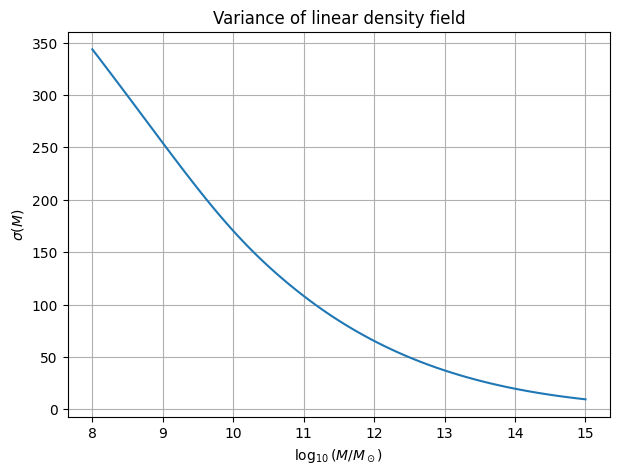

In [4]:
## Exemplo de consulta: sigma(M)
# Usamos sigma_functions.fstm(log10(M)) para obter o valor de σ(M).
masses = np.linspace(8, 15, 100)   # log10(M/Msun)
sigmas = [sigma_functions.fstm(m) for m in masses]

plt.figure(figsize=(7,5))
plt.plot(masses, sigmas)
plt.xlabel(r"$\log_{10}(M/M_\odot)$")
plt.ylabel(r"$\sigma(M)$")
plt.title("Variance of linear density field")
plt.grid(True)
plt.show()


In [5]:
## Exemplo de consulta: limites de integração da função de massa
# Aqui obtemos os limites [lmInf, lmSup] baseados na escolha do mass_function_type.
limits = sigma_functions.integration_limits_mass_function(
    mass_function_type="ST",
    lmin=8.0,
    lmax=15.0,
    dinamicLimits=True,
)
print("Integration limits for mass function:", limits)


Integration limits for mass function: [8.0, 15.0]


In [6]:
## Exemplo adicional: relação sigma ↔ massa
# Vamos pegar um intervalo de sigma e ver a faixa correspondente de massa.
sgm_min, sgm_max = 0.5, 2.0
mass_range = sigma_functions.massRangeSigma(sgm_min, sgm_max)

print(f"Sigma range [{sgm_min}, {sgm_max}] corresponds to mass range {mass_range}")


Sigma range [0.5, 2.0] corresponds to mass range [15.0, 15.0]
